# Studio e implementazione di ProtoLens
In questo progetto vogliamo utilizzare Protolens per analizzare un dataset "legale" Unfair-Tos.

In [1]:
import os
import pandas as pd
from datasets import load_dataset

# 1. Carica il dataset
dataset = load_dataset("coastalcph/lex_glue", "unfair_tos")

# 2. Crea la cartella base
base_dir = "Datasets_LexGlue"
os.makedirs(base_dir, exist_ok=True)

/home/inginf2026simcap/.virtualenvs/ProtoLensOR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Questo datset è molto sbilanciato. Potrebbero esserci molte complicazioni nell' apprendimento.


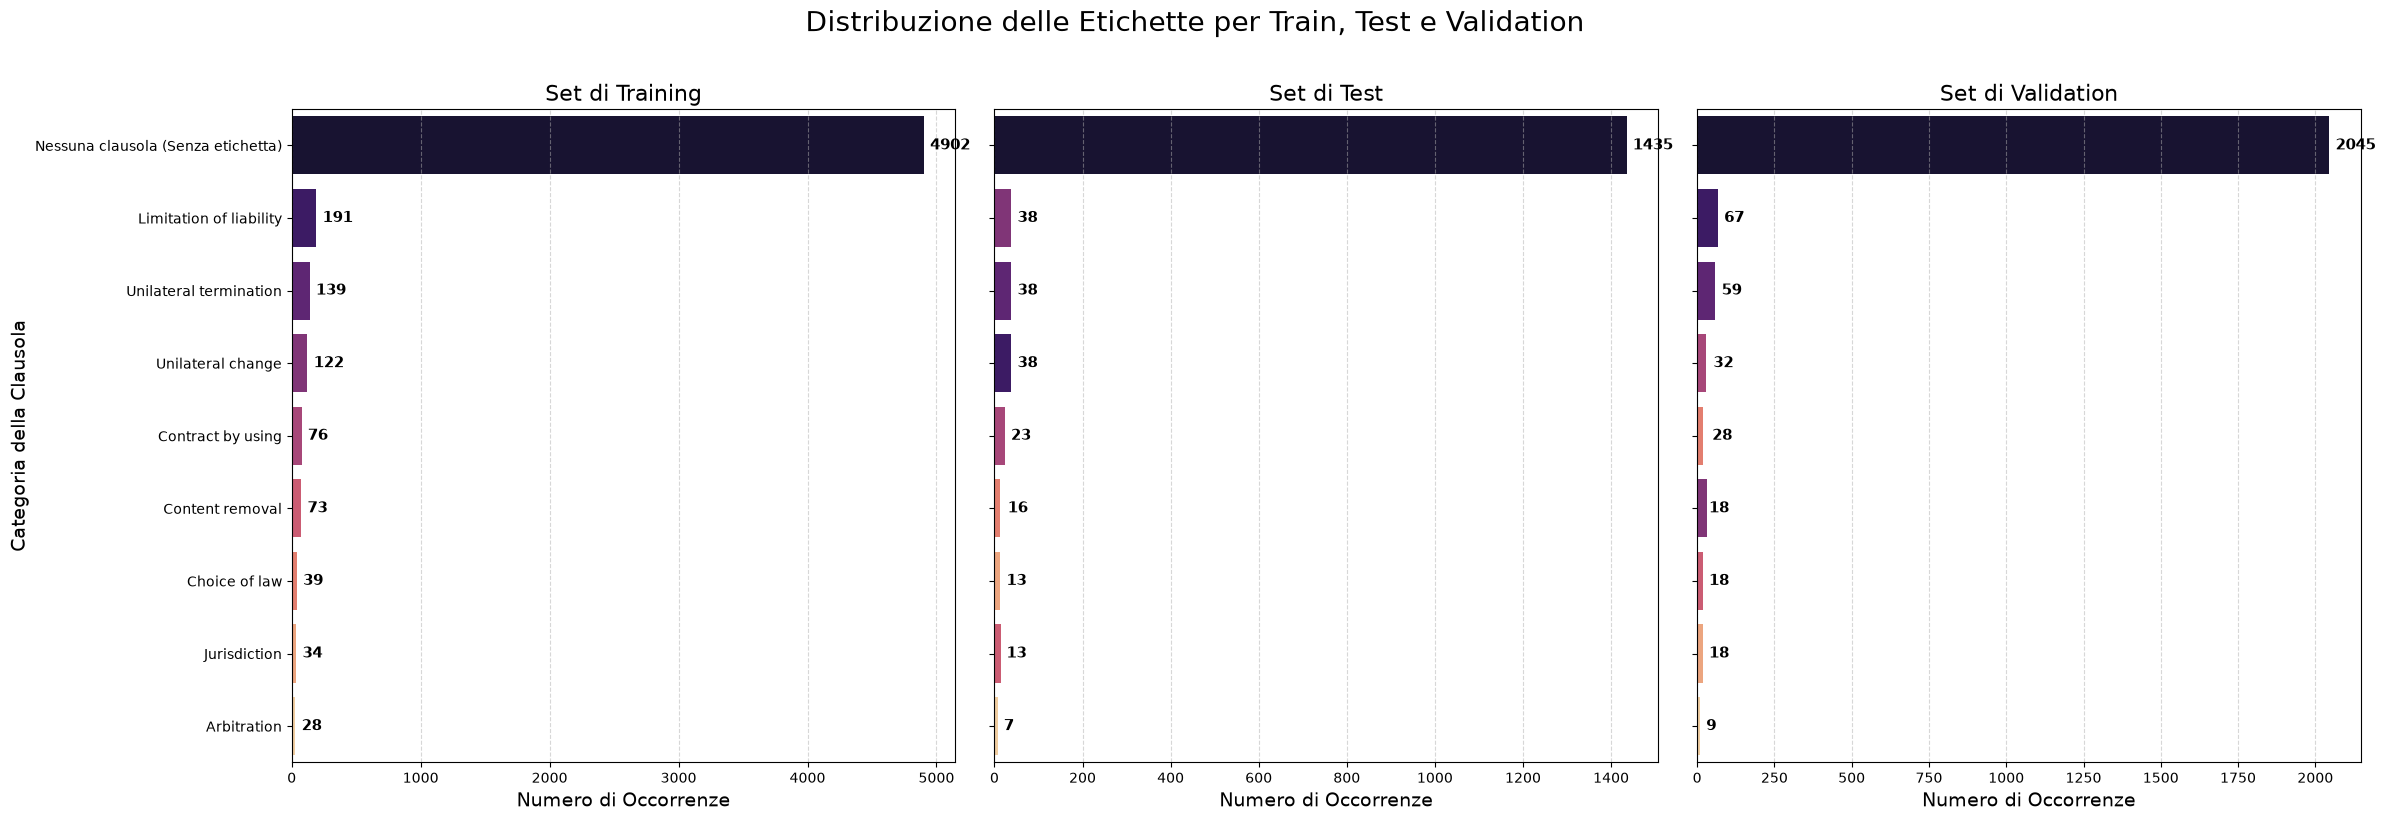

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_label_distribution(dataset_split, title_suffix=''):
    label_names = dataset_split.features['labels'].feature.names

    all_labels = []
    for sublist in dataset_split['labels']:
        if len(sublist) == 0:
            all_labels.append("Nessuna clausola (Senza etichetta)")
        else:
            for label_id in sublist:
                all_labels.append(label_names[label_id])

    label_counts = pd.Series(all_labels).value_counts().reset_index()
    label_counts.columns = ['Classe', 'Frequenza']
    return label_counts

# Get distributions for all three splits
train_label_counts = get_label_distribution(dataset['train'], 'Train')
test_label_counts = get_label_distribution(dataset['test'], 'Test')
validation_label_counts = get_label_distribution(dataset['validation'], 'Validation')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
fig.suptitle('Distribuzione delle Etichette per Train, Test e Validation', fontsize=20, y=1.02)

# Plot Train distribution
sns.barplot(
    ax=axes[0],
    data=train_label_counts,
    x='Frequenza',
    y='Classe',
    hue='Classe',
    palette='magma',
    legend=False
)
axes[0].set_title('Set di Training', fontsize=16)
axes[0].set_xlabel('Numero di Occorrenze', fontsize=14)
axes[0].set_ylabel('Categoria della Clausola', fontsize=14)
axes[0].grid(axis='x', alpha=0.5, linestyle='--')
for index, value in enumerate(train_label_counts['Frequenza']):
    offset = max(train_label_counts['Frequenza']) * 0.01
    axes[0].text(value + offset, index, str(value), va='center', fontsize=11, fontweight='bold')

# Plot Test distribution
sns.barplot(
    ax=axes[1],
    data=test_label_counts,
    x='Frequenza',
    y='Classe',
    hue='Classe',
    palette='magma',
    legend=False
)
axes[1].set_title('Set di Test', fontsize=16)
axes[1].set_xlabel('Numero di Occorrenze', fontsize=14)
axes[1].set_ylabel('') # Remove y-label for middle plot
axes[1].grid(axis='x', alpha=0.5, linestyle='--')
for index, value in enumerate(test_label_counts['Frequenza']):
    offset = max(test_label_counts['Frequenza']) * 0.01
    axes[1].text(value + offset, index, str(value), va='center', fontsize=11, fontweight='bold')

# Plot Validation distribution
sns.barplot(
    ax=axes[2],
    data=validation_label_counts,
    x='Frequenza',
    y='Classe',
    hue='Classe',
    palette='magma',
    legend=False
)
axes[2].set_title('Set di Validation', fontsize=16)
axes[2].set_xlabel('Numero di Occorrenze', fontsize=14)
axes[2].set_ylabel('') # Remove y-label for rightmost plot
axes[2].grid(axis='x', alpha=0.5, linestyle='--')
for index, value in enumerate(validation_label_counts['Frequenza']):
    offset = max(validation_label_counts['Frequenza']) * 0.01
    axes[2].text(value + offset, index, str(value), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Dopo aver osservato questi dati notiamo quanto il dataset sia sbilanciato, per affrontare il training ho dovuto apportare delle modifiche al codice sorgente. <br>
In *utils.py* ho modificato il metodo e trasformato in questo modo.

In [ ]:
def get_data_loader(dataset, dataset_path, world_size, rank, batch_size, max_length, bert_model_name, distributed = True):
    data_file = dataset_path
    base = dataset_path.rsplit("/", 2)[0]
    tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')
    if dataset == "IMDB":
        # data_file = dataset_path
        texts, labels = load_imdb_data(dataset_path)
        train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.5, random_state=42)

    if dataset.startswith("class_") or dataset in ["Hotel", "Amazon", "Rotten_Tomatoes", "Steam", "Yelp", "go_emotion", "Consumer", "ISEAR", "DBPedia","UnfairToS"]  :
      train_file = os.path.join(os.path.join(base, dataset), "train.csv")

      # decommentare questo codice se si vuole utilizzare un dataset ridotto/ampliato per l' addestramento
      # if os.path.isfile(dataset_path):
      #     # Se dataset_path è un file specifico es. train_small.csv, usalo direttamente
      #     train_file = dataset_path
      # else:
      #     # Altrimenti mantieni la logica per le cartelle
      #     train_file = os.path.join(os.path.join(base, dataset), "train.csv")

    if dataset == "UnfairToS":
        val_file = os.path.join(os.path.join(base, dataset), "validation_holdout.csv")
    else:
        val_file = os.path.join(os.path.join(base, dataset), "test.csv")

    train_texts,  train_labels = load_data(train_file)
    val_texts, val_labels = load_data(val_file)

    print(f"\n[DEBUG DATASET] Sto caricando il file di Train da: {train_file}")
    print(f"[DEBUG DATASET] Numero totali di frasi nel Train: {len(train_texts)}")
    print(f"[DEBUG DATASET] Prime 2 frasi di esempio: {train_texts[:2]}\n")

    # train_dataset = TextClassificationDataset(train_texts, train_labels, tokenizer, max_length)
    # val_dataset = TextClassificationDataset(val_texts, val_labels, tokenizer, max_length)

    # #queste due erano gia commentate
    # # train_sampler = torch.utils.data.distributed.DistributedSampler(train_dataset, num_replicas=world_size, rank=rank)
    # # train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, sampler=train_sampler)

    # train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # --- NUOVO: oversampling della classe minoritaria ---
    train_dataset = TextClassificationDataset(train_texts, train_labels, tokenizer, max_length)
    val_dataset = TextClassificationDataset(val_texts, val_labels, tokenizer, max_length)
    label_counts = Counter(train_labels)
    sample_weights = [1.0 / label_counts[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, pin_memory=True)
    # ------------------------------------------------------
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    return train_dataloader, val_dataloader, tokenizer, train_texts

La funzione `get_data_loader` ha il compito di caricare i dataset di training e validazione, tokenizzare il testo e creare i `DataLoader` per l'uso nel training di un modello. È progettata per gestire diversi tipi di dataset e include una tecnica di oversampling per affrontare lo sbilanciamento delle classi.

Ecco i passaggi principali:

1.  **Parametri della Funzione**: Accetta `dataset` (nome del dataset), `dataset_path` (percorso del file principale o cartella), `world_size`, `rank`, `batch_size`, `max_length`, `bert_model_name` e `distributed` (per configurazioni distribuite).

2.  **Inizializzazione del Tokenizer**: Utilizza `AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')` per caricare un tokenizer pre-addestrato dal modello specificato. Questo tokenizer verrà usato per convertire il testo in formati numerici comprensibili al modello.

3.  **Determinazione dei Percorsi dei File**: Il codice determina i percorsi per i file di training (`train_file`) e di validazione (`val_file`).
    *   Per il dataset `IMDB`, il caricamento è specifico.
    *   Per vari altri dataset (inclusi quelli che iniziano con `class_` e `UnfairToS`), costruisce il percorso del file `train.csv` all'interno di una sottocartella specifica del dataset.
    *   Per `UnfairToS`, il file di validazione è `validation_holdout.csv`, altrimenti è `test.csv`.

4.  **Caricamento dei Dati**: Chiama una funzione `load_data` per caricare i testi e le etichette dai file `train_file` e `val_file`.

5.  **Creazione dei Dataset PyTorch**: `TextClassificationDataset` crea oggetti dataset PyTorch dai testi e dalle etichette caricate, utilizzando il tokenizer e la `max_length` specificati.

6.  **Oversampling della Classe Minoritaria (NUOVO)**: Questa è la parte più significativa e modificata per gestire lo sbilanciamento delle classi:
    *   Calcola la frequenza di ogni etichetta nel dataset di training usando `Counter(train_labels)`.
    *   Assegna un peso a ciascun campione nel dataset di training inversamente proporzionale alla frequenza della sua classe (`1.0 / label_counts[label]`). Questo significa che i campioni delle classi meno frequenti avranno pesi maggiori.
    *   Crea un `WeightedRandomSampler` utilizzando questi pesi. Il campionatore selezionerà casualmente campioni per il batch di training, ma con una probabilità basata sui pesi, favorendo così le classi minoritarie.
    *   Il `train_dataloader` viene quindi creato usando questo `sampler`, garantendo che i batch di training contengano una rappresentazione più bilanciata delle classi, anche se il dataset originale è sbilanciato.

7.  **Creazione del DataLoader di Validazione**: Il `val_dataloader` viene creato senza campionamento pesato, poiché lo shuffling e il bilanciamento non sono tipicamente necessari per la validazione.

8.  **Valori di Ritorno**: La funzione restituisce il `train_dataloader`, il `val_dataloader`, il `tokenizer` e i `train_texts`.

## Introduzione a ProtoLens

Per iniziare bisogna scaricare tutte le librerie mancati necessarie per il progetto

In [1]:
%pip install GPUtil
%pip install python-docx
%pip install MemTracker


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /home/inginf2026simcap/.virtualenvs/ProtoLensOR/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /home/inginf2026simcap/.virtualenvs/ProtoLensOR/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /home/inginf2026simcap/.virtualenvs/ProtoLensOR/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Avviamo lo script che permette di creare i prototipi iniziali e creare il primo dataset per l' esperimento.

In [2]:
import sys
import os

# Puntiamo DIRETTAMENTE alla tua cartella reale, mai più /tmp/!
project_path = '/home/inginf2026simcap/ProtoLensOR'

os.chdir(project_path)

if project_path not in sys.path:
    sys.path.insert(0, project_path)

print("Ora opero correttamente da:", os.getcwd())

Ora opero correttamente da: /home/inginf2026simcap/ProtoLensOR


In [3]:
from build_or_dataset import main as build_or_dataset
from args import pnfrl_args
from experiment2 import train_main
from prototype_category_mapping import get_prototype_activations, build_prototype_category_map
import os, torch, pandas as pd
from build_prototypesV2 import build_prototypes_per_category

out_dir = build_or_dataset(base_folder='./Datasets_LexGlue')

pnfrl_args.base_folder = './Datasets_LexGlue'
pnfrl_args.data_set = 'UnfairToS'
pnfrl_args.dataset_path = os.path.join(out_dir, 'train.csv')
pnfrl_args.num_classes = 2
pnfrl_args.batch_size = 16
pnfrl_args.epoch = 1
pnfrl_args.log = None

#build_prototypes(pnfrl_args) vecchia versione

centers_path, csv_path, metadata_path, prototype_num = build_prototypes_per_category(
    multilabel_csv_path=os.path.join(out_dir, 'train_multilabel.csv'),
    base_folder='./Datasets_LexGlue',
    data_set='UnfairToS',
    bert_model_name='all-mpnet-base-v2',
    prototypes_per_class= 10, #fa 24 prototipi
)

pnfrl_args.prototype_num = prototype_num

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/inginf2026simcap/.virtualenvs/ProtoLensOR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 5532
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1607
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2275
    })
})
Positivi (OR) nel train: 630 / 5532 (11.4%)
Positivi (OR) nel test (=validation di training):  172 / 1607 (10.7%)
File salvati in: ./Datasets_LexGlue/UnfairToS
[1/4] Carico le clausole etichettate da: ./Datasets_LexGlue/UnfairToS/train_multilabel.csv
[2/4] Carico il modello di embedding: all-mpnet-base-v2


/home/inginf2026simcap/.virtualenvs/ProtoLensOR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[3/4] Categoria 0: 191 clausole disponibili
[3/4] Categoria 1: 139 clausole disponibili
[3/4] Categoria 2: 122 clausole disponibili
[3/4] Categoria 3: 73 clausole disponibili
[3/4] Categoria 4: 76 clausole disponibili
[3/4] Categoria 5: 39 clausole disponibili
[3/4] Categoria 6: 34 clausole disponibili
[3/4] Categoria 7: 28 clausole disponibili
[4/4] Fatto. prototype_num = 80 (8 categorie x 10 prototipi ciascuna)
  centers   -> ./Datasets_LexGlue/UnfairToS/all-mpnet-base-v2/UnfairToS_cluster_80_centers.npy  (shape (80, 768))
  sentences -> ./Datasets_LexGlue/UnfairToS/all-mpnet-base-v2/UnfairToS_cluster_80_to_sub_sentence.csv
  metadata  -> ./Datasets_LexGlue/UnfairToS/all-mpnet-base-v2/UnfairToS_prototype_metadata.json


/bin/bash: riga 1: ./: È una directory


In [23]:
import inspect
import experiment2


print(inspect.getsource(experiment2.train_model))

"""
build_or_dataset.py

Prepara il dataset LexGLUE unfair_tos per un training binario "OR":
    label = 1  se almeno una delle 8 categorie di clausola sleale e' presente
    label = 0  altrimenti

Salva due gruppi di file per ciascuno split (train / test / validation_holdout):
- <split>.csv            -> colonne 'review','sentiment' (0/1), compatibili
                             con utils.load_data() / get_data_loader()
- <split>_multilabel.csv -> colonne 'review', label_0 ... label_7 (0/1),
                             stesso ordine di righe di <split>.csv, usate SOLO
                             per l'analisi post-hoc prototipo -> categoria,
                             mai per il training.

IMPORTANTE sulla nomenclatura (per coerenza con get_data_loader in utils.py,
che nel progetto usa 'test.csv' come validation set durante il training):
- train.csv               <- split 'train' di HF
- test.csv                <- split 'test' di HF (usato come validation dal loop di training)
- 

In [21]:
import os, time
f = os.path.join(project_path, 'experiment2.py')  # metti il nome vero
print(time.ctime(os.path.getmtime(f)))

Mon Sep  7 15:28:28 2026


## File mancanti nel progetto

### *build_or_dataset.py*

Prepara il dataset LexGLUE unfair_tos trasformandolo in un task di classificazione binaria (presenza di almeno una clausola sleale).

Logica "**OR**": sentiment=1 se la clausola è presente (una o più categorie), 0 altrimenti. <br>
Output Duale: Genera per ogni split (train, test, validation) due file CSV: <br>
**[split].csv**: Formato binario (review, sentiment) per il training del modello.<br>
**[split]_multilabel.csv**: Formato esteso (review, label_0...label_7) per l'analisi post-hoc.

*Nota sulla Nomenclatura: Segue il mapping richiesto da utils.py dove il test di HuggingFace funge da validazione interna, preservando validation come set di test finale ("holdout").*

---

### *build_prototypes.py*

Genera prototipi supervisionati per ProtoLens applicando **K-Means** separatamente su ciascuna delle 8 categorie del dataset.<br>
Input: File train_multilabel.csv (clausole etichettate con soli 1 o 0 in corrispondenda delle opportune classi).

Processo: **Embedding** (SentenceTransformer) $\rightarrow$ K-Means per categoria $\rightarrow$ Estrazione centroidi e pool di frasi vicine.

Output: Centroidi (.npy), pool di frasi (.csv) e metadati descrittivi (.json).

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datasets import load_dataset
from build_or_dataset import main as build_or_dataset

# Re-initialize out_dir here to ensure it's defined
out_dir = build_or_dataset(base_folder='./Datasets_LexGlue')

# Load the original dataset if not already loaded in this session
# This assumes 'dataset' is a global variable from a previous cell, but re-loading is safer.
dataset = load_dataset("coastalcph/lex_glue", "unfair_tos")

multilabel_csv_path = os.path.join(out_dir, 'train_multilabel.csv')
binary_csv_path = os.path.join(out_dir, 'train.csv')

# Load DataFrames
df_multilabel = pd.read_csv(multilabel_csv_path)
df_binary = pd.read_csv(binary_csv_path)

print("--- Struttura di train_multilabel.csv (multilabel) ---")
print(f"Righe: {df_multilabel.shape[0]}, Colonne: {df_multilabel.shape[1]}")
print("Nomi delle colonne:", df_multilabel.columns.tolist())
print("Prime 3 righe:")
display(df_multilabel.head(3))
print("\n")

print("--- Struttura di train.csv (single-label, da build_or_dataset) ---")
print(f"Righe: {df_binary.shape[0]}, Colonne: {df_binary.shape[1]}")
print("Nomi delle colonne:", df_binary.columns.tolist())
print("Prime 3 righe:")
display(df_binary.head(3))
print("\n")

print("--- Struttura del dataset originale (train split) ---")
print(f"Righe: {dataset['train'].num_rows}, Colonne: {len(dataset['train'].column_names)}")
print("Nomi delle colonne:", dataset['train'].column_names)
# Display some data for the original dataset (if possible and meaningful, otherwise skip)
# display(pd.DataFrame(dataset['train'][:3])) # This would load to memory, might be heavy
print("Esempio di features per le prime 3 righe:")
for i in range(3):
    print(f"  Testo: {dataset['train'][i]['text'][:70]}...")
    print(f"  Etichette: {dataset['train'][i]['labels']}")
print("\n")

# Prepare data for plotting
structure_data = pd.DataFrame({
    'Tipo di Dataset': [
        'train_multilabel',
        'train (single-label, da build_or_dataset)',
        'Dataset originale (train split)'
    ],
    'Numero di Colonne': [
        df_multilabel.shape[1],
        df_binary.shape[1],
        len(dataset['train'].column_names) # Original dataset column count
    ]
})


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 5532
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1607
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2275
    })
})
Positivi (OR) nel train: 630 / 5532 (11.4%)
Positivi (OR) nel test (=validation di training):  172 / 1607 (10.7%)
File salvati in: ./Datasets_LexGlue/UnfairToS
--- Struttura di train_multilabel.csv (multilabel) ---
Righe: 5532, Colonne: 9
Nomi delle colonne: ['review', 'label_0', 'label_1', 'label_2', 'label_3', 'label_4', 'label_5', 'label_6', 'label_7']
Prime 3 righe:


,review,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7
0,notice to california subscribers : you may can...,0,0,0,0,0,0,0,0
1,"if you subscribed using your apple id , refund...",0,0,0,0,0,0,0,0
2,"if you wish to request a refund , please visit...",0,0,0,0,0,0,0,0




--- Struttura di train.csv (single-label, da build_or_dataset) ---
Righe: 5532, Colonne: 2
Nomi delle colonne: ['review', 'sentiment']
Prime 3 righe:


,review,sentiment
0,notice to california subscribers : you may can...,0
1,"if you subscribed using your apple id , refund...",0
2,"if you wish to request a refund , please visit...",0




--- Struttura del dataset originale (train split) ---
Righe: 5532, Colonne: 2
Nomi delle colonne: ['text', 'labels']
Esempio di features per le prime 3 righe:
  Testo: notice to california subscribers : you may cancel your subscription , ...
  Etichette: []
  Testo: if you subscribed using your apple id , refunds are handled by apple ,...
  Etichette: []
  Testo: if you wish to request a refund , please visit https://getsupport.appl...
  Etichette: []




### Tuning dei parametri



Questa funzione incapsula l'intero processo di addestramento per una singola configurazione di iperparametri durante la fase di tuning.

**Cosa fa nel dettaglio:**
* **Configurazione dinamica:** Aggiorna temporaneamente i parametri globali (`lr`, `window_size`, `dataset_path`) per l'esperimento corrente.
* **Addestramento:** Avvia il training del modello richiamando `train_main`.
* **Monitoraggio Visivo:** Genera e salva in automatico due grafici fondamentali per valutare l'overfitting e le prestazioni:
  1. L'andamento della *Cross Entropy Loss* in fase di training.
  2. Le metriche di validazione (*F1-Score* e *Accuracy*).
* **Sicurezza:** Ripristina il percorso del dataset originale a fine esecuzione per evitare conflitti ("bug a cascata") nelle iterazioni successive del ciclo for.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os

def run_tuning_experiment(lr, window, dataset_path, save_dir):

    old_dataset = pnfrl_args.dataset_path

    pnfrl_args.learning_rate = lr
    pnfrl_args.window_size = window
    pnfrl_args.dataset_path = dataset_path
    pnfrl_args.data_set = "UnfairToS"
    pnfrl_args.epoch = 20
    save_dir = save_dir


    print(f"--- Lancio esperimento con file: {dataset_path} ---")
    # Leggiamo al volo le prime righe del file csv passatogli
    df_check = pd.read_csv(dataset_path)
    print(f"Dimensione del file rilevata dal notebook: {df_check.shape[0]} righe.")


    model, val_loader, score, history_loss, history_f1, history_acc = train_main(pnfrl_args)

    epoche = range(1, len(history_loss) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Grafico 1: Training Loss
    ax1.plot(epoche, history_loss, label='Training Loss', color='red', marker='o')
    ax1.set_title('Andamento della Cross Entropy Loss')
    ax1.set_xlabel('Epoche')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Grafico 2: Validation Metrics (F1-score e Accuracy)
    ax2.plot(epoche, history_f1, label='Validation F1-score', color='blue', marker='s')
    ax2.plot(epoche, history_acc, label='Validation Accuracy', color='green', marker='^')
    ax2.set_title('Metriche di Validazione')
    ax2.set_xlabel('Epoche')
    ax2.set_ylabel('Score')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()

    # 3. Salva l'immagine su Drive (opzionale, ma utilissimo per la tesi)
    plot_path = os.path.join(save_dir, f'learning_curves_{nome_modello}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Grafico salvato in: {plot_path}")
    plt.close()
    # ripristina il dataset originale (per possibili bug futuri)
    pnfrl_args.dataset_path = old_dataset

    return model, val_loader, score

Questa funzione misura quanto sono "sensate" e coerenti le spiegazioni fornite dal modello, confrontando le categorie dei prototipi attivati con le categorie reali del testo.

**Cosa fa nel dettaglio:**
* **Elaborazione Dati:** Carica il dataset multilabel e individua le categorie reali (ground truth) per ogni riga.
* **Estrazione Prototipi:** Interroga il modello tramite `explain_prediction` per farsi restituire i top-K prototipi più influenti per ogni predizione.
* **Calcolo Metriche (Match Rate):** Controlla se la categoria del prototipo più importante (Top-1), dei primi due (Top-2) o dei primi K (Top-K) è effettivamente presente tra le categorie reali di quel testo.
* **Output:** Restituisce un riassunto globale delle metriche e un DataFrame con i dettagli granulari (riga per riga) per analisi successive.

In [6]:
def evaluate_explanation_quality(model, multilabel_csv_path, device,
                                  top_k=3, batch_size=16, num_categories=8):

    df = pd.read_csv(multilabel_csv_path)
    label_cols = [f"label_{c}" for c in range(num_categories)]
    df["true_label"] = (df[label_cols].sum(axis=1) > 0).astype(int)

    records = []
    texts_all = df["review"].tolist()

    model.eval()
    for start in tqdm(range(0, len(texts_all), batch_size), desc="Explaining test set"):
        batch_rows = df.iloc[start:start + batch_size]
        batch_texts = batch_rows["review"].tolist()

        results = model.explain_prediction(batch_texts, device=device, top_k=top_k)

        for (_, row), r in zip(batch_rows.iterrows(), results):
            true_categories = [c for c in range(num_categories) if row[f"label_{c}"] == 1]
            pred_label = r["predicted_class"]
            true_label = row["true_label"]

            proto_categories = [p.get("category") for p in r["top_prototypes"] if p.get("category") is not None]

            # --- CALCOLO MATCH ---
            top1_category = proto_categories[0] if len(proto_categories) > 0 else None

            top1_match = top1_category in true_categories if top1_category is not None else False
            top2_match = any(c in true_categories for c in proto_categories[:2])
            topk_match = any(c in true_categories for c in proto_categories)

            records.append({
                "review": row["review"],
                "true_label": true_label,
                "pred_label": pred_label,
                "correct_classification": true_label == pred_label,
                "true_categories": true_categories,
                "proto_categories_topk": proto_categories,
                "top1_match": top1_match,
                "top2_match": top2_match,
                "topk_match": topk_match,
            })

    detail_df = pd.DataFrame(records)

    mask = (detail_df["true_label"] == 1) & (detail_df["correct_classification"])
    relevant = detail_df[mask]

    metrics = {
        "n_test_total": len(detail_df),
        "n_unfair_true": int((detail_df["true_label"] == 1).sum()),
        "n_unfair_correctly_classified": int(mask.sum()),
        "top1_category_match_rate": float(relevant["top1_match"].mean()) if len(relevant) else float("nan"),
        "top2_category_match_rate": float(relevant["top2_match"].mean()) if len(relevant) else float("nan"),
        f"top{top_k}_category_match_rate": float(relevant["topk_match"].mean()) if len(relevant) else float("nan"),
    }

    return metrics, detail_df



**Cosa fa nel dettaglio:**
* **Classificazione Standard:** Esegue l'inferenza sull'intero validation set calcolando il classico *Classification Report* di scikit-learn (Precision, Recall, F1-Score).
* **Integrazione XAI:** Richiama la funzione `evaluate_explanation_quality` per ottenere le metriche sui prototipi (Top-K Match Rate).
* **Archiviazione:** Compila un resoconto testuale completo e lo salva in un file `.txt` nella cartella di destinazione (usando lo stesso nome del modello per facilitarne il recupero).
* **Output:** Restituisce le metriche delle spiegazioni per consentire la creazione della classifica globale (Grid Search).

In [7]:
from sklearn.metrics import classification_report
import torch
import os
from tqdm import tqdm

def evaluate_and_save_report(model, val_loader, device, save_dir, nome_modello,
                              multilabel_csv_path, top_k=3, num_categories=8):
    """
    Calcola classification report + metriche di explanation quality per un modello,
    e le salva in un .txt con lo stesso nome dell'immagine relativa.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            special_tokens_mask = batch['special_tokens_mask'].to(device)
            original_text = batch['original_text']
            labels = batch['label']

            logits, _, _, _ = model(
                input_ids=input_ids, attention_mask=attention_mask,
                special_tokens_mask=special_tokens_mask, mode="test",
                original_text=original_text, current_batch_num=0,
                return_prototype_activations=True
            )
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    report_str = classification_report(
        all_labels, all_preds, target_names=["fair", "unfair"], digits=3
    )

    # Metriche sulla qualità delle spiegazioni (prototipi)
    expl_metrics, detail_df = evaluate_explanation_quality(
        model, multilabel_csv_path, device, top_k=top_k, num_categories=num_categories
    )

    # Costruzione contenuto del txt
    lines = [f"=== Report per modello: {nome_modello} ===\n"]
    lines.append("--- Classification Report ---")
    lines.append(report_str)
    lines.append("\n--- Explanation Quality Metrics ---")
    for k, v in expl_metrics.items():
        lines.append(f"{k}: {v}")

    txt_path = os.path.join(save_dir, f'learning_curves_{nome_modello}.txt')
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))

    print(f"📄 Report salvato in: {txt_path}")

    return expl_metrics, detail_df

In [7]:
save_dir = '/home/inginf2026simcap/Saved_Models/UnfairToS_Best_Model/Tuning_Results2'

os.makedirs(save_dir, exist_ok=True)
print("Cartella creata in:", os.path.abspath(save_dir))

Cartella creata in: /home/inginf2026simcap/Saved_Models/UnfairToS_Best_Model/Tuning_Results2


Questa cella esegue la ricerca a griglia (*Grid Search*) combinando diverse configurazioni di iperparametri (`learning_rate` e `window_size`).

**Flusso operativo:**
* **Addestramento & Curve:** Allena il modello tramite `run_tuning_experiment` e salva i grafici di convergenza (Loss, F1, Accuracy).
* **Valutazione Congiunta:** Richiama `evaluate_and_save_report` per calcolare sia le performance di classificazione (F1-score) sia la qualità interpretativa dei prototipi (Top-1, Top-2, Top-3 Match Rate), salvando il resoconto testuale dedicato per ogni configurazione.
* **Gestione Risorse:** Pulisce esplicitamente la memoria VRAM della GPU al termine di ogni iterazione per prevenire errori di memoria (*Out Of Memory*).
* **Riepilogo Globale:** Costruisce, visualizza e salva su disco (`tuning_base_summary.csv`) la classifica finale ordinata in base alle prestazioni di validazione.

In [ ]:
import pandas as pd
import os
import torch

results = []

learning_rates = [
    #1e-4,
    5e-4,
    #1e-3
]

windows = [
   # 3,
    5,
  # 7
]

# Definiamo i percorsi assoluti per andare sul sicuro
save_dir = '/home/inginf2026simcap/ProtoLensOR/Saved_Models/UnfairToS_Best_Model/Tuning_Results2'
os.makedirs(save_dir, exist_ok=True)

best_score_globale = 0.0
miglior_modello = ""

print("Inizio Grid Search Semplificata (Solo Addestramento)... 🚀\n")

for lr in learning_rates:
    for window in windows:
        nome_modello = f"LR_{lr}_Win_{window}"

        print(f"\n{'='*50}")
        print(f" Avvio Addestramento: {nome_modello}")
        print(f"{'='*50}")

        # 1. Addestra il modello (Assicurati che NON ci sia plt.show() nella funzione!)
        # Passiamo solo i 3 parametri richiesti dalla tua funzione
        model, val_loader, score = run_tuning_experiment(
            lr, window, os.path.join(out_dir, "train.csv"), save_dir
        )

        print(f"✅ Addestramento completato per {nome_modello} | Validation Score (F1): {score:.4f}")

        expl_metrics, detail_df = evaluate_and_save_report(
            model, val_loader, device, save_dir, nome_modello,
            multilabel_csv_path=os.path.join(out_dir, "test_multilabel.csv")
        )

        # 2. Aggiorna la classifica
        results.append({
            "Modello": nome_modello,
            "LR": lr,
            "Window": window,
            "Val_F1_Score": score
        })

        # 3. Gestione del salvataggio del modello migliore
        # (Se train_model sta già salvando in automatico in args.model_path, qui ne teniamo solo traccia testuale)
        if score > best_score_globale:
            best_score_globale = score
            miglior_modello = nome_modello
            print(f"🏆 {nome_modello} è il nuovo modello leader!")

        # 4. Svuota la cache della GPU per evitare Out Of Memory (OOM) tra un ciclo e l'altro
        del model
        torch.cuda.empty_cache()

# --- CLASSIFICA FINALE ---
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Val_F1_Score", ascending=False).reset_index(drop=True)

print("\n\n" + "*"*25)
print(" CLASSIFICA FINALE DEL TUNING")
print("*"*25)
display(df_results)

# Salva la classifica base
risultati_finali_path = os.path.join(save_dir, 'tuning_base_summary.csv')
df_results.to_csv(risultati_finali_path, index=False)
print(f"\n Tabella riassuntiva salvata in: {risultati_finali_path}")
print(f"\nIl vincitore assoluto da analizzare in seguito è: {miglior_modello}")

Inizio Grid Search Semplificata (Solo Addestramento)... 🚀


 Avvio Addestramento: LR_0.0005_Win_5
--- Lancio esperimento con file: ./Datasets_LexGlue/UnfairToS/train.csv ---
Dimensione del file rilevata dal notebook: 5532 righe.
2026-09-29 09:54:03,394 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transformers/all-mpnet-base-v2/resolve/main/tokenizer_config.json HTTP/1.1" 307 0
2026-09-29 09:54:03,409 - [DEBUG] - https://huggingface.co:443 "HEAD /api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/tokenizer_config.json HTTP/1.1" 200 0
Distribuzione primo batch: Counter({1: 8, 0: 8})
2026-09-29 09:54:03,470 - [INFO] - No device provided, using cuda:0
2026-09-29 09:54:03,601 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transformers/all-mpnet-base-v2/resolve/main/modules.json HTTP/1.1" 307 0
2026-09-29 09:54:03,614 - [DEBUG] - https://huggingface.co:443 "HEAD /api/resolve-cache/models/sentence-transformers/all-mpnet-

/home/inginf2026simcap/.virtualenvs/ProtoLensOR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


2026-09-29 09:54:03,747 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transformers/all-mpnet-base-v2/resolve/main/config_sentence_transformers.json HTTP/1.1" 307 0
2026-09-29 09:54:03,761 - [DEBUG] - https://huggingface.co:443 "HEAD /api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/config_sentence_transformers.json HTTP/1.1" 200 0
2026-09-29 09:54:03,764 - [INFO] - Loading SentenceTransformer model from sentence-transformers/all-mpnet-base-v2.
2026-09-29 09:54:03,899 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transformers/all-mpnet-base-v2/resolve/main/config_sentence_transformers.json HTTP/1.1" 307 0
2026-09-29 09:54:03,913 - [DEBUG] - https://huggingface.co:443 "HEAD /api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/config_sentence_transformers.json HTTP/1.1" 200 0
2026-09-29 09:54:04,046 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transfor

/home/inginf2026simcap/.virtualenvs/ProtoLensOR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


2026-09-29 09:54:05,759 - [DEBUG] - https://huggingface.co:443 "HEAD /sentence-transformers/all-mpnet-base-v2/resolve/main/2_Normalize/config.json HTTP/1.1" 404 0
2026-09-29 09:54:05,762 - [DEBUG] - Could not load 'config.json' from 'sentence-transformers/all-mpnet-base-v2': 404 Client Error. (Request ID: Root=1-6abb6985-566bd2d21981e6ab5fddb478;d603f3f7-e8eb-4e51-81de-899806583b5a)

Entry Not Found for url: https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/2_Normalize/config.json.
2026-09-29 09:54:05,903 - [DEBUG] - https://huggingface.co:443 "GET /api/models/sentence-transformers/all-mpnet-base-v2 HTTP/1.1" 200 None


Batches: 100%|██████████| 1/1 [00:00<00:00, 113.72it/s]


Caricato prototype_metadata.json (80 prototipi mappati)
2026-09-29 09:54:07,414 - [INFO] - CE loss: 0.7147
grad MDN: 0.0
grad prototypes: 4.133774280548096
2026-09-29 09:54:08,279 - [INFO] - CE loss: 0.6910
grad MDN: 0.0
grad prototypes: 4.103510856628418
2026-09-29 09:54:09,194 - [INFO] - CE loss: 0.7204
grad MDN: 0.0
grad prototypes: 4.0783233642578125
2026-09-29 09:54:10,033 - [INFO] - CE loss: 0.7003
grad MDN: 0.0
grad prototypes: 4.040788650512695
2026-09-29 09:54:10,856 - [INFO] - CE loss: 0.6884
grad MDN: 0.0
grad prototypes: 4.005194187164307
2026-09-29 09:54:11,694 - [INFO] - CE loss: 0.6582
grad MDN: 0.0
grad prototypes: 3.9642398357391357
2026-09-29 09:54:12,528 - [INFO] - CE loss: 0.6725
grad MDN: 0.0
grad prototypes: 3.9196672439575195
2026-09-29 09:54:13,366 - [INFO] - CE loss: 0.6634
grad MDN: 0.0
grad prototypes: 3.8746674060821533
2026-09-29 09:54:14,286 - [INFO] - CE loss: 0.6877
grad MDN: 0.0
grad prototypes: 3.823357105255127
2026-09-29 09:54:15,127 - [INFO] - CE lo

In [ ]:
import os
import shutil

os.environ["TOKENIZERS_PARALLELISM"] = "false"


# 1. Definisci il percorso di destinazione fisso sul tuo Google Drive
save_dir = './Saved_Models/UnfairToS_Best_Model'

os.makedirs(save_dir, exist_ok=True)

# 2. Recupera il percorso locale dove experiment2.py ha appena salvato il modello
# (pnfrl_args.folder_path contiene la directory corrente dell'esperimento)
local_log_dir = pnfrl_args.folder_path

print(f"Copia dei file da: {local_log_dir}")
print(f"Verso: {save_dir}\\n")

# 3. Copia il modello (model.pth) e il file di log (log.txt)
files_to_save = ['model.pth', 'log.txt']

for file_name in files_to_save:
    src_file = os.path.join(local_log_dir, file_name)
    dst_file = os.path.join(save_dir, file_name)

    if os.path.exists(src_file):
        shutil.copy(src_file, dst_file)
        print(f"✅ Salvato correttamente: {dst_file}")
    else:
        print(f"❌ Attenzione: {src_file} non trovato.")

print("\n🚀 Salvataggio su Google Drive completato! Ora puoi ricaricare il modello in futuro.")

Copia dei file da: log_folder/Amazon/_Amazon_fine-tune_all-mpnet-base-v2_gNum_6_ws_5_e_25_pNum_20_lr0.0005
Verso: /content/drive/MyDrive/ProtoLens/Saved_Models/UnfairToS_Best_Model\n
✅ Salvato correttamente: /content/drive/MyDrive/ProtoLens/Saved_Models/UnfairToS_Best_Model/model.pth
❌ Attenzione: log_folder/Amazon/_Amazon_fine-tune_all-mpnet-base-v2_gNum_6_ws_5_e_25_pNum_20_lr0.0005/log.txt non trovato.

🚀 Salvataggio su Google Drive completato! Ora puoi ricaricare il modello in futuro.


In [ ]:
from sklearn.metrics import classification_report
import torch

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:  # usa il nome corretto (val_dataloader o val_loader)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        special_tokens_mask = batch['special_tokens_mask'].to(device)
        original_text = batch['original_text']
        labels = batch['label']

        logits, _, _, _ = model(
            input_ids=input_ids, attention_mask=attention_mask,
            special_tokens_mask=special_tokens_mask, mode="test",
            original_text=original_text, current_batch_num=0,
            return_prototype_activations=True
        )
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
print(classification_report(all_labels, all_preds, target_names=["fair", "unfair"], digits=3))

              precision    recall  f1-score   support

        fair      0.978     0.831     0.899      2045
      unfair      0.358     0.835     0.501       230

    accuracy                          0.832      2275
   macro avg      0.668     0.833     0.700      2275
weighted avg      0.915     0.832     0.859      2275



In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from utils import TextClassificationDataset

# --- carica direttamente test.csv, senza dipendere da variabili già in memoria ---
test_path = os.path.join(pnfrl_args.base_folder, pnfrl_args.data_set, "test.csv")
test_df_eval = pd.read_csv(test_path)

test_texts = test_df_eval['review'].tolist()
test_labels = test_df_eval['sentiment'].tolist()

test_dataset = TextClassificationDataset(test_texts, test_labels, model.tokenizer, model.max_length)
test_dataloader_eval = DataLoader(test_dataset, batch_size=pnfrl_args.batch_size, shuffle=False, pin_memory=True)

# --- valutazione ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_dataloader_eval:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        special_tokens_mask = batch['special_tokens_mask'].to(device)
        original_text = batch['original_text']
        labels = batch['label']

        logits, _, _, _ = model(
            input_ids=input_ids, attention_mask=attention_mask,
            special_tokens_mask=special_tokens_mask, mode="test",
            original_text=original_text, current_batch_num=0,
            return_prototype_activations=True
        )
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["fair", "unfair"], digits=3))

              precision    recall  f1-score   support

        fair      0.980     0.870     0.922      1435
      unfair      0.441     0.855     0.582       172

    accuracy                          0.869      1607
   macro avg      0.711     0.863     0.752      1607
weighted avg      0.923     0.869     0.886      1607



In [ ]:
import torch.nn.functional as F

P_final = F.normalize(model.prototype_vectors.detach().cpu(), dim=1)
S_final = P_final @ P_final.T

almost_identical = (S_final > 0.999).fill_diagonal_(False).sum().item()
print(f"Coppie quasi identiche dopo 1 epoca a LR basso: {almost_identical}")
print(S_final[:5, :5].round(decimals=3))

Coppie quasi identiche dopo 1 epoca a LR basso: 0
tensor([[ 1.0000, -0.9860, -0.9400,  0.9910,  0.9550],
        [-0.9860,  1.0000,  0.9070, -0.9850, -0.9670],
        [-0.9400,  0.9070,  1.0000, -0.9320, -0.8530],
        [ 0.9910, -0.9850, -0.9320,  1.0000,  0.9640],
        [ 0.9550, -0.9670, -0.8530,  0.9640,  1.0000]])


In [ ]:
import torch.nn.functional as F

P_final = F.normalize(model.prototype_vectors.detach().cpu(), dim=1)
S_final = P_final @ P_final.T

almost_identical = (S_final > 0.999).fill_diagonal_(False).sum().item()
print(f"Coppie quasi identiche dopo 1 epoca a LR basso: {almost_identical}")
print(S_final[:20, :20].round(decimals=3))

Coppie quasi identiche dopo 1 epoca a LR basso: 0
tensor([[ 1.0000, -0.9860, -0.9400,  0.9910,  0.9550,  0.9910, -0.9880, -0.9820,
         -0.9710, -0.9800, -0.9860,  0.9950,  0.9960, -0.9800,  0.9800,  0.9730,
          0.9900,  0.9930, -0.9840,  0.8730],
        [-0.9860,  1.0000,  0.9070, -0.9850, -0.9670, -0.9780,  0.9920,  0.9870,
          0.9440,  0.9610,  0.9910, -0.9860, -0.9900,  0.9800, -0.9800, -0.9750,
         -0.9880, -0.9800,  0.9870, -0.8910],
        [-0.9400,  0.9070,  1.0000, -0.9320, -0.8530, -0.9440,  0.8970,  0.8810,
          0.9490,  0.9400,  0.9000, -0.9390, -0.9330,  0.8900, -0.9060, -0.9110,
         -0.9300, -0.9520,  0.8970, -0.7830],
        [ 0.9910, -0.9850, -0.9320,  1.0000,  0.9640,  0.9880, -0.9860, -0.9820,
         -0.9610, -0.9710, -0.9840,  0.9960,  0.9920, -0.9780,  0.9840,  0.9630,
          0.9840,  0.9830, -0.9850,  0.8540],
        [ 0.9550, -0.9670, -0.8530,  0.9640,  1.0000,  0.9390, -0.9740, -0.9740,
         -0.9230, -0.9390, -0.9680,  

In [ ]:
import json
with open(os.path.join(model.model_spec_folder, f"{pnfrl_args.data_set}_prototype_metadata.json")) as f:
    metadata = json.load(f)

for i in range(24):
    print(i, "categoria", metadata[str(i)]["category"])

0 categoria 0
1 categoria 0
2 categoria 0
3 categoria 1
4 categoria 1
5 categoria 1
6 categoria 2
7 categoria 2
8 categoria 2
9 categoria 3
10 categoria 3
11 categoria 3
12 categoria 4
13 categoria 4
14 categoria 4
15 categoria 5
16 categoria 5
17 categoria 5
18 categoria 6
19 categoria 6
20 categoria 6
21 categoria 7
22 categoria 7
23 categoria 7


In [ ]:
import numpy as np

proto_init = np.load(
    os.path.join(
        model.model_spec_folder,
        str(pnfrl_args.data_set)+"_cluster_"+str(pnfrl_args.prototype_num)+"_centers.npy"
    )
)

P = torch.tensor(proto_init)
P = F.normalize(P, dim=1)

S = P @ P.T
print(S[:5, :5].round(decimals=3))

tensor([[1.0000, 0.7620, 0.7740, 0.6030, 0.6740],
        [0.7620, 1.0000, 0.5830, 0.5790, 0.6100],
        [0.7740, 0.5830, 1.0000, 0.7060, 0.6720],
        [0.6030, 0.5790, 0.7060, 1.0000, 0.8730],
        [0.6740, 0.6100, 0.6720, 0.8730, 1.0000]])


## Usare un DataFrame

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "score",
    ascending=False
)

results_df

,learning_rate,window_size,score
0,0.0005,3,0


Passiamo ora alla valutazione del nostro modello mediante l' applicazione di alcuni esempi:

In [ ]:
import types
import torch.nn.functional as F
import types
import numpy as np

def explain_prediction(self, texts, device, top_k=3):
    self.eval()
    if isinstance(texts, str):
        texts = [texts]

    original_len = len(texts)
    padded = False
    if original_len == 1:
        texts = texts + [texts[0]]
        padded = True

    encoding = self.tokenizer(
        texts, return_tensors='pt', max_length=self.max_length,
        padding='max_length', truncation=True, add_special_tokens=True,
        return_offsets_mapping=True, return_special_tokens_mask=True
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    special_tokens_mask = encoding['special_tokens_mask'].to(device)

    with torch.no_grad():
        logits, _, _, similarity = self.forward(
            input_ids=input_ids, attention_mask=attention_mask,
            special_tokens_mask=special_tokens_mask, mode="test",
            original_text=texts, current_batch_num=0,
            return_prototype_activations=True
        )

    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)
    fc_weight = self.fc.weight.detach().cpu().numpy()
    sim_np = similarity.detach().cpu().numpy()

    results = []
    for i, text in enumerate(texts):
        pred_class = int(preds[i].item())
        contribution = sim_np[i] * fc_weight[pred_class]
        top_idx = np.argsort(contribution)[::-1][:top_k]

        top_prototypes = []
        for p in top_idx:
            entry = {
                "prototype_id": int(p),
                "activation": float(sim_np[i, p]),
                "contribution": float(contribution[p]),
            }
            if self.prototype_metadata is not None:
                meta = self.prototype_metadata.get(str(p))
                if meta:
                    entry["category"] = meta["category"]
                    entry["representative_sentence"] = meta["sentence"]
            top_prototypes.append(entry)

        results.append({
            "text": text,
            "predicted_class": pred_class,
            "probability": float(probs[i, pred_class].item()),
            "top_prototypes": top_prototypes,
        })

    if padded:
        results = results[:original_len]
    return results

# aggancia il metodo aggiornato ALLA SPECIFICA istanza model, bypassando la classe originale
model.explain_prediction = types.MethodType(explain_prediction, model)

In [ ]:
multilabel_df = pd.read_csv(os.path.join(out_dir, 'test_multilabel.csv'))

label_cols = [f'label_{c}' for c in range(8)]
multilabel_df['true_label'] = (multilabel_df[label_cols].sum(axis=1) > 0).astype(int)

# alcuni esempi VERAMENTE unfair (almeno una categoria presente)
unfair_examples = multilabel_df[multilabel_df['true_label'] == 1].sample(10, random_state=42)

# alcuni esempi VERAMENTE fair (nessuna categoria presente)
fair_examples = multilabel_df[multilabel_df['true_label'] == 0].sample(10, random_state=42)

test_df = pd.concat([unfair_examples, fair_examples])

In [ ]:
results = model.explain_prediction(test_df['review'].tolist(), device=device, top_k=3)

for r, (_, row) in zip(results, test_df.iterrows()):
    true_label = row['true_label']
    pred_label = r['predicted_class']
    true_categories = [c for c in range(8) if row[f'label_{c}'] == 1]
    correct = "✓" if true_label == pred_label else "✗"

    print(f"{correct} Testo: {r['text']}...")
    print(f"   Verità: {'UNFAIR' if true_label else 'fair'} (categorie vere: {true_categories or 'nessuna'})")
    print(f"   Predetto: {'UNFAIR' if pred_label else 'fair'} (prob {r['probability']:.3f})")
    for proto in r['top_prototypes']:
        cat = proto.get('category', '?')
        sent = proto.get('representative_sentence', '')
        match = "← corrisponde!" if cat in true_categories else ""
        print(f"     Prototipo {proto['prototype_id']} (categoria {cat}, contributo {proto['contribution']:.3f}) {match}")
        print(f"       -> \"{sent}...\"")

    print()

✗ Testo: we can not always prevent this misuse of our services , and you agree that we are not responsible for any such misuse . 
...
   Verità: UNFAIR (categorie vere: [0])
   Predetto: fair (prob 0.856)
     Prototipo 20 (categoria 6, contributo 0.062) 
       -> "this is indicated in the chart as well . ) 
..."
     Prototipo 9 (categoria 3, contributo 0.048) 
       -> "viber may remove or modify any content without notice or liability at any time in viber 's sole discretion . 
..."
     Prototipo 6 (categoria 2, contributo 0.037) 
       -> "we may change , suspend , or discontinue any or all of the services at any time , including the availability of any product , feature , database , or content . 
..."

✓ Testo: we may have little or no control over such sites or developers and , accordingly , you acknowledge and agree that ( i ) we are not responsible for the availability of such external sites , content or applications ; ( ii ) we are not responsible or liable for any content 

### Metrica di plausibilita' delle spiegazioni
Per ogni esempio **VERAMENTE** unfair e **CORRETTAMENTE** classificato come unfair, controlla se la categoria del prototipo piu' attivato (top-1) e/o una delle categorie tra i top-k prototipi piu' attivati coincide con una delle categorie realmente violate dalla clausola.
Ritorna un dict con le metriche aggregate e un DataFrame con il dettaglio per-esempio (utile per ispezionare casi giusti/sbagliati dopo).

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def evaluate_explanation_quality(model, multilabel_csv_path, device,
                                  top_k=3, batch_size=16, num_categories=8):

    df = pd.read_csv(multilabel_csv_path)
    label_cols = [f"label_{c}" for c in range(num_categories)]
    df["true_label"] = (df[label_cols].sum(axis=1) > 0).astype(int)

    records = []
    texts_all = df["review"].tolist()

    model.eval()
    for start in tqdm(range(0, len(texts_all), batch_size), desc="Explaining test set"):
        batch_rows = df.iloc[start:start + batch_size]
        batch_texts = batch_rows["review"].tolist()

        results = model.explain_prediction(batch_texts, device=device, top_k=top_k)

        for (_, row), r in zip(batch_rows.iterrows(), results):
            true_categories = [c for c in range(num_categories) if row[f"label_{c}"] == 1]
            pred_label = r["predicted_class"]
            true_label = row["true_label"]

            proto_categories = [p.get("category") for p in r["top_prototypes"] if p.get("category") is not None]

            # --- CALCOLO MATCH ---
            top1_category = proto_categories[0] if len(proto_categories) > 0 else None

            top1_match = top1_category in true_categories if top1_category is not None else False
            # NUOVO: Calcolo Top-2 (controlla se c'è un match nei primi 2 prototipi)
            top2_match = any(c in true_categories for c in proto_categories[:2])
            topk_match = any(c in true_categories for c in proto_categories)

            records.append({
                "review": row["review"],
                "true_label": true_label,
                "pred_label": pred_label,
                "correct_classification": true_label == pred_label,
                "true_categories": true_categories,
                "proto_categories_topk": proto_categories,
                "top1_match": top1_match,
                "top2_match": top2_match, # Aggiunto
                "topk_match": topk_match,
            })

    detail_df = pd.DataFrame(records)

    mask = (detail_df["true_label"] == 1) & (detail_df["correct_classification"])
    relevant = detail_df[mask]

    metrics = {
        "n_test_total": len(detail_df),
        "n_unfair_true": int((detail_df["true_label"] == 1).sum()),
        "n_unfair_correctly_classified": int(mask.sum()),
        "top1_category_match_rate": float(relevant["top1_match"].mean()) if len(relevant) else float("nan"),
        "top2_category_match_rate": float(relevant["top2_match"].mean()) if len(relevant) else float("nan"), # Aggiunto
        f"top{top_k}_category_match_rate": float(relevant["topk_match"].mean()) if len(relevant) else float("nan"),
    }

    return metrics, detail_df

metrics, detail_df = evaluate_explanation_quality(
    model,
    os.path.join(out_dir, "test_multilabel.csv"),   # o validation_multilabel.csv per il numero finale
    device=device,
    top_k=3,
)

print(metrics)

Explaining test set:   0%|          | 0/101 [00:00<?, ?it/s]

{'n_test_total': 1607, 'n_unfair_true': 172, 'n_unfair_correctly_classified': 147, 'top1_category_match_rate': 0.22448979591836735, 'top3_category_match_rate': 0.4965986394557823}


In [ ]:
print(model.fc.bias)
print(model.fc.weight)

Parameter containing:
tensor([ 0.1946, -0.1633], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[ 0.5672, -0.5838, -0.2361,  0.5197,  0.4873,  0.6880, -0.6878, -0.7665,
         -0.4890, -0.6946, -0.6882,  0.6963,  0.5866, -0.5761,  0.4538,  0.3902,
          0.5036,  0.6419, -0.6918,  0.1640, -0.7314, -0.7442, -0.6130,  0.7396],
        [-0.6512,  0.6794,  0.4780, -0.7106, -0.3537, -0.6661,  0.7558,  0.7443,
          0.6008,  0.4675,  0.6020, -0.7288, -0.5076,  0.7325, -0.5674, -0.6586,
         -0.6903, -0.7555,  0.6759, -0.4697,  0.6766,  0.6709,  0.6419, -0.6944]],
       device='cuda:0', requires_grad=True)


In [ ]:
test_text = "We will not be liable for any indirect or consequential damages arising from your use of the service."

words, words_in_order, df, vocab = model.get_words(original_text=[test_text])

candidate_indices = df[0].nonzero()[1]
candidates_alpha_order = [words[i] for i in candidate_indices]

import re
tokens = re.findall(r"\b\w+\b", test_text.lower())
window = pnfrl_args.window_size
true_order_ngrams = [" ".join(tokens[i:i+window]) for i in range(len(tokens) - window + 1)]

print("Ordine visto dalla maschera (CountVectorizer, alfabetico):")
print(candidates_alpha_order[:15])
print()
print("Ordine reale nel testo:")
print(true_order_ngrams[:15])
print()
print("Coincidono?", candidates_alpha_order[:len(true_order_ngrams)] == true_order_ngrams)

Ordine visto dalla maschera (CountVectorizer, alfabetico):
['any indirect or', 'arising from your', 'be liable for', 'consequential damages arising', 'damages arising from', 'for any indirect', 'from your use', 'indirect or consequential', 'liable for any', 'not be liable', 'of the service', 'or consequential damages', 'use of the', 'we will not', 'will not be']

Ordine reale nel testo:
['we will not', 'will not be', 'not be liable', 'be liable for', 'liable for any', 'for any indirect', 'any indirect or', 'indirect or consequential', 'or consequential damages', 'consequential damages arising', 'damages arising from', 'arising from your', 'from your use', 'your use of', 'use of the']

Coincidono? False


In [ ]:
import numpy as np

model.eval()
all_sims = []
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        special_tokens_mask = batch['special_tokens_mask'].to(device)
        original_text = batch['original_text']

        _, _, _, similarity = model(
            input_ids=input_ids, attention_mask=attention_mask,
            special_tokens_mask=special_tokens_mask, mode="test",
            original_text=original_text, current_batch_num=0,
            return_prototype_activations=True
        )
        all_sims.append(similarity.detach().cpu().numpy())
        if i >= 9:   # ~10 batch, per velocità
            break

all_sims = np.concatenate(all_sims, axis=0)
print("Shape:", all_sims.shape)
print("Media globale:", all_sims.mean().round(4))
print("Std globale:", all_sims.std().round(4))
print("Media per prototipo:", all_sims.mean(axis=0).round(3))
print("Std per prototipo:", all_sims.std(axis=0).round(3))
print("\nRange (max-min) per riga, primi 10 esempi:")
for row in all_sims[:10]:
    print(f"  min={row.min():.3f}  max={row.max():.3f}  range={row.max()-row.min():.3f}")

Shape: (160, 24)
Media globale: 0.0003
Std globale: 0.0682
Media per prototipo: [ 0.018 -0.016  0.003  0.024  0.015  0.015 -0.014 -0.013 -0.001 -0.007
 -0.015  0.022  0.01  -0.01   0.023  0.006  0.011  0.007 -0.011 -0.019
 -0.025 -0.006 -0.022  0.013]
Std per prototipo: [0.067 0.066 0.072 0.063 0.053 0.068 0.065 0.064 0.068 0.068 0.065 0.066
 0.067 0.069 0.064 0.07  0.069 0.072 0.067 0.055 0.068 0.069 0.067 0.071]

Range (max-min) per riga, primi 10 esempi:
  min=-0.033  max=0.028  range=0.061
  min=-0.085  max=0.063  range=0.149
  min=-0.050  max=0.034  range=0.084
  min=-0.082  max=0.045  range=0.127
  min=-0.109  max=0.054  range=0.163
  min=-0.093  max=0.119  range=0.213
  min=-0.096  max=0.040  range=0.136
  min=-0.077  max=0.070  range=0.147
  min=-0.061  max=0.036  range=0.098
  min=-0.043  max=0.045  range=0.088


In [ ]:
import numpy as np
import torch

texts_sample = test_df['review'].tolist()[:200]  # limita per velocità, aumenta se vuoi
batch_size = 16
model.eval()
all_sims = []

with torch.no_grad():
    for start in range(0, len(texts_sample), batch_size):
        batch_texts = texts_sample[start:start + batch_size]
        encoding = model.tokenizer(
            batch_texts, return_tensors='pt', max_length=model.max_length,
            padding='max_length', truncation=True, add_special_tokens=True,
            return_offsets_mapping=True, return_special_tokens_mask=True
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        special_tokens_mask = encoding['special_tokens_mask'].to(device)

        _, _, _, similarity = model(
            input_ids=input_ids, attention_mask=attention_mask,
            special_tokens_mask=special_tokens_mask, mode="test",
            original_text=batch_texts, current_batch_num=0,
            return_prototype_activations=True
        )
        all_sims.append(similarity.detach().cpu().numpy())

all_sims = np.concatenate(all_sims, axis=0)
print("Shape:", all_sims.shape)
print("Media globale:", all_sims.mean().round(4))
print("Std globale:", all_sims.std().round(4))
print("Std per prototipo:", all_sims.std(axis=0).round(3))
print("\nRange (max-min) per riga, primi 10 esempi:")
for row in all_sims[:10]:
    print(f"  min={row.min():.3f}  max={row.max():.3f}  range={row.max()-row.min():.3f}")

Shape: (20, 24)
Media globale: -0.0002
Std globale: 0.0701
Std per prototipo: [0.07  0.064 0.06  0.06  0.06  0.069 0.066 0.07  0.067 0.07  0.069 0.067
 0.072 0.079 0.066 0.076 0.072 0.072 0.065 0.088 0.069 0.065 0.06  0.076]

Range (max-min) per riga, primi 10 esempi:
  min=-0.085  max=0.061  range=0.147
  min=-0.159  max=0.071  range=0.230
  min=-0.089  max=0.095  range=0.184
  min=-0.175  max=0.127  range=0.303
  min=-0.094  max=0.098  range=0.193
  min=-0.073  max=0.084  range=0.157
  min=-0.064  max=0.050  range=0.114
  min=-0.020  max=0.022  range=0.041
  min=-0.250  max=0.192  range=0.441
  min=-0.083  max=0.068  range=0.151


In [ ]:
import numpy as np
fc_w = model.fc.weight.detach().cpu().numpy()  # (num_classes, num_prototypes)
print("Shape fc.weight:", fc_w.shape)
print("Norma L2 per classe:", np.linalg.norm(fc_w, axis=1).round(3))

w_unfair = fc_w[1]  # classe UNFAIR
print("\nPesi (classe UNFAIR):", w_unfair.round(3))
print("Media |peso|:", np.abs(w_unfair).mean().round(4))
print("Std |peso|:", w_unfair.std().round(4))
print("Coefficiente di variazione:", (w_unfair.std() / (np.abs(w_unfair).mean() + 1e-8)).round(3))

Shape fc.weight: (2, 24)
Norma L2 per classe: [2.942 3.141]

Pesi (classe UNFAIR): [-0.651  0.679  0.478 -0.711 -0.354 -0.666  0.756  0.744  0.601  0.468
  0.602 -0.729 -0.508  0.733 -0.567 -0.659 -0.69  -0.756  0.676 -0.47
  0.677  0.671  0.642 -0.694]
Media |peso|: 0.6325
Std |peso|: 0.641
Coefficiente di variazione: 1.013


In [ ]:
import types
import numpy as np
import torch
import torch.nn.functional as F

def explain_prediction(self, texts, device, top_k=3, span_top_ngrams=3):
    self.eval()
    if isinstance(texts, str):
        texts = [texts]

    original_len = len(texts)
    if original_len == 1:
        texts = texts + [texts[0]]

    encoding = self.tokenizer(
        texts, return_tensors='pt', max_length=self.max_length,
        padding='max_length', truncation=True, add_special_tokens=True,
        return_offsets_mapping=True, return_special_tokens_mask=True
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    special_tokens_mask = encoding['special_tokens_mask'].to(device)

    with torch.no_grad():
        words, words_in_order, df, vocab = self.get_words(original_text=texts)
        candidates_embeddings, candidate_words, chunk_similarity = self.get_start_point(
            texts, df, words, mode="test", batch_num=0, prototype_vec=self.prototype_vectors
        )
        chunk_similarity_flat = chunk_similarity.permute(0, 2, 1).reshape(-1, 512)
        pi, mu, sigma = self.mdn(chunk_similarity_flat)

        mask = self.AdaptiveMask(
            mu, sigma, pi, batch_size=input_ids.shape[0], num_prototypes=self.num_prototypes
        ).reshape(input_ids.shape[0], self.num_prototypes, -1)

        x = self.bert._first_module().auto_model(
            input_ids, attention_mask, output_hidden_states=False
        ).last_hidden_state

        Z_prime = self.mean_pooling(x, mask.permute(0, 2, 1)).permute(0, 2, 1)
        cos = torch.nn.CosineSimilarity(dim=2, eps=1e-6)
        similarity = cos(Z_prime, self.prototype_vectors.unsqueeze(0))
        logits = self.fc(similarity)

    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)
    fc_weight = self.fc.weight.detach().cpu().numpy()
    sim_np = similarity.detach().cpu().numpy()
    pi_np = pi.detach().cpu().numpy()
    mu_np = mu.detach().cpu().numpy()
    sigma_np = sigma.detach().cpu().numpy()

    results = []
    for i in range(original_len):
        text = texts[i]
        pred_class = int(preds[i].item())
        contribution = sim_np[i] * fc_weight[pred_class]
        top_idx = np.argsort(contribution)[::-1][:top_k]

        top_prototypes = []
        for p in top_idx:
            entry = {
                "prototype_id": int(p),
                "activation": float(sim_np[i, p]),
                "contribution": float(contribution[p]),
            }
            if self.prototype_metadata is not None:
                meta = self.prototype_metadata.get(str(p))
                if meta:
                    entry["category"] = meta["category"]
                    entry["representative_sentence"] = meta["sentence"]

            # --- span dinamico estratto dal testo corrente (come Fig. 5/6 del paper) ---
            # row = i * self.num_prototypes + int(p)
            # g_star = int(np.argmax(pi_np[row]))          # componente gaussiana dominante
            # center = float(mu_np[row, g_star])
            # half_width = float(sigma_np[row, g_star])

            # cand_list = candidate_words[i]
            # lo = max(0, int(round(center - half_width)))
            # hi = min(len(cand_list), int(round(center + half_width)) + 1)
            # window_ngrams = [w for w in cand_list[lo:hi] if w != "None"]

            # seen = set()
            # window_ngrams = [w for w in window_ngrams if not (w in seen or seen.add(w))]
            # entry["extracted_span_candidates"] = window_ngrams[:span_top_ngrams]

            row = i * self.num_prototypes + int(p)
            g_star = int(np.argmax(pi_np[row]))
            center = float(mu_np[row, g_star])
            half_width = float(sigma_np[row, g_star])

            cand_list = candidate_words[i]
            real_k = sum(1 for w in cand_list if w != "None")

            lo = max(0, min(int(round(center - half_width)), max(real_k - 1, 0)))
            hi = max(lo + 1, min(int(round(center + half_width)) + 1, real_k))
            window_ngrams = [w for w in cand_list[lo:hi] if w != "None"]

            if not window_ngrams and real_k > 0:
                # fallback: il candidato reale con similarity più alta per QUESTO prototipo specifico
                sim_vec = chunk_similarity[i, :real_k, p].detach().cpu().numpy()
                best = int(np.argmax(sim_vec))
                window_ngrams = [cand_list[best]]

            seen = set()
            window_ngrams = [w for w in window_ngrams if not (w in seen or seen.add(w))]
            entry["extracted_span_candidates"] = window_ngrams[:span_top_ngrams]

            located = None
            for ng in window_ngrams:
                pos = text.lower().find(ng)
                if pos != -1:
                    located = text[pos:pos + len(ng)]
                    break
            entry["extracted_span"] = located if located else (window_ngrams[0] if window_ngrams else None)

            top_prototypes.append(entry)

        results.append({
            "text": text,
            "predicted_class": pred_class,
            "probability": float(probs[i, pred_class].item()),
            "top_prototypes": top_prototypes,
        })

    return results

model.explain_prediction = types.MethodType(explain_prediction, model)

In [ ]:
r = model.explain_prediction("We will not be liable for any indirect or consequential damages arising from your use of the service.", device=device, top_k=3)[0]
for proto in r["top_prototypes"]:
    print(proto["prototype_id"], proto.get("category"), proto["contribution"], "->", proto["extracted_span"])

9 3 0.04617574065923691 -> consequential damages arising
8 2 0.028887638822197914 -> be liable for
20 6 0.027414053678512573 -> be liable for


In [ ]:
r = model.explain_prediction("academia.edu reserves the right , at any time and without prior notice , to remove or disable access to any collective content , including , but not limited to , collective content that academia.edu , at its sole discretion , considers to be in violation of these terms or otherwise harmful to the site or services .", device=device, top_k=3)[0]
for proto in r["top_prototypes"]:
    print(proto["prototype_id"], proto.get("category"), proto["contribution"], "->", proto["extracted_span"])

15 5 0.10213357955217361 -> and without prior
17 5 0.09891369938850403 -> access to any
21 7 0.0868859514594078 -> any time and


In [ ]:
r = model.explain_prediction("academia.edu reserves the right , at any time and without prior notice , to remove or disable access to any collective content , including , but not limited to , collective content that academia.edu , at its sole discretion , considers to be in violation of these terms or otherwise harmful to the site or services .", device=device, top_k=3)[0]
for proto in r["top_prototypes"]:
    print(proto["prototype_id"], proto.get("category"), proto["contribution"], "->", proto["extracted_span"])

15 5 0.10213357955217361 -> and without prior
17 5 0.09891369938850403 -> access to any
21 7 0.0868859514594078 -> any time and


In [ ]:
r = model.explain_prediction("any other trademarks , service marks , logos , trade names and any other proprietary designations are the trademarks or registered trademarks of their respective parties .", device=device, top_k=3)[0]
for proto in r["top_prototypes"]:
    print(proto["prototype_id"], proto.get("category"), proto["contribution"], "->", proto["extracted_span"])

9 3 0.11216601729393005 -> trademarks service marks
11 3 0.09405358880758286 -> designations are the
23 7 0.09099230915307999 -> designations are the


In [ ]:
r = model.explain_prediction("any other trademarks , service marks , logos , trade names and any other proprietary designations are the trademarks or registered trademarks of their respective parties .", device=device, top_k=3)[0]
for proto in r["top_prototypes"]:
    print(proto["prototype_id"], proto.get("category"), proto["contribution"], "->", proto["extracted_span"])

9 3 0.11216601729393005 -> trademarks service marks
11 3 0.09405358880758286 -> designations are the
23 7 0.09099230915307999 -> designations are the


In [ ]:
for p in top_idx:
    row = i*self.num_prototypes + p
    g = np.argmax(pi_np[row])

    print(
        p,
        "mu =", mu_np[row, g],
        "sigma =", sigma_np[row, g],
        "pi =", pi_np[row, g]
    )

NameError: name 'top_idx' is not defined

In [ ]:
P = F.normalize(model.prototype_vectors, dim=1)
#P = model.prototype_vectors.detach().cpu()
S = P @ P.T

print(S[6,7])
print(S[6,13])
print(S[7,13])

tensor(0.9970, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.9909, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.9942, device='cuda:0', grad_fn=<SelectBackward0>)


In [ ]:
def analyze_prototype_collapse(model, prototypes_per_class=3, num_categories=8):
    P = F.normalize(model.prototype_vectors, dim=1).detach().cpu()
    S = (P @ P.T).numpy()
    n = S.shape[0]

    category_of = [i // prototypes_per_class for i in range(n)]

    same_cat_sims = []
    cross_cat_sims = []
    for i in range(n):
        for j in range(i + 1, n):
            if category_of[i] == category_of[j]:
                same_cat_sims.append(S[i, j])
            else:
                cross_cat_sims.append(S[i, j])

    # quante coppie sono "quasi identiche" (soglia arbitraria ma ragionevole: 0.95)
    threshold = 0.95
    near_duplicate_pairs = [(i, j, S[i, j]) for i in range(n) for j in range(i + 1, n) if S[i, j] > threshold]

    return {
        "mean_similarity_same_category": float(np.mean(same_cat_sims)),
        "mean_similarity_cross_category": float(np.mean(cross_cat_sims)),
        "n_near_duplicate_pairs (>%.2f)" % threshold: len(near_duplicate_pairs),
        "n_total_pairs": n * (n - 1) // 2,
        "worst_cross_category_pairs": sorted(
            [(i, j, category_of[i], category_of[j], float(S[i, j]))
             for i, j in [(a, b) for a in range(n) for b in range(a + 1, n) if category_of[a] != category_of[b]]],
            key=lambda x: -x[4]
        )[:10],
    }, S

stats, S = analyze_prototype_collapse(model)
print(stats)

In [ ]:
torch.max(torch.abs(model.prototype_vectors[6] - model.prototype_vectors[7]))

tensor(0.0133, device='cuda:0', grad_fn=<MaxBackward1>)

In [ ]:
torch.max(torch.abs(model.prototype_vectors[6] - model.prototype_vectors[13]))

tensor(0.0304, device='cuda:0', grad_fn=<MaxBackward1>)

In [ ]:
torch.norm(model.prototype_vectors[6] - model.prototype_vectors[7])

tensor(0.1021, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)

In [ ]:
proto_init = np.load(
    os.path.join(
        model.model_spec_folder,
        str(pnfrl_args.data_set)+"_cluster_"+str(pnfrl_args.prototype_num)+"_centers.npy"
    )
)

P = torch.tensor(proto_init)
P = F.normalize(P, dim=1)

S = P @ P.T

print(S[6,7])
print(S[6,13])
print(S[7,13])

tensor(0.7689)
tensor(0.6611)
tensor(0.8390)


In [ ]:
print(sim_np[i, top_idx])

NameError: name 'sim_np' is not defined

In [ ]:
text = "we can not always prevent this misuse of our services, and you agree that we are not responsible for any such misuse."

encoding = model.tokenizer([text, text], return_tensors='pt', max_length=model.max_length,
                            padding='max_length', truncation=True, add_special_tokens=True,
                            return_offsets_mapping=True, return_special_tokens_mask=True)

with torch.no_grad():
    words, words_in_order, df, vocab = model.get_words(original_text=[text, text])
    candidates_embeddings, candidate_words, chunk_similarity = model.get_start_point(
        [text, text], df, words, mode="test", batch_num=0, prototype_vec=model.prototype_vectors
    )

cand_list = candidate_words[0]
real_k = sum(1 for w in cand_list if w != "None")
sim_matrix = chunk_similarity[0, :real_k, :].detach().cpu().numpy()  # (n_candidati_reali, num_prototypes)

print(f"{real_k} candidati reali, {sim_matrix.shape[1]} prototipi\n")
print("Similarity media per candidato (su tutti i prototipi) — un candidato 'hub' avrà media alta e ovunque:")
for idx in range(real_k):
    print(f"  [{idx:3d}] media={sim_matrix[idx].mean():.3f}  std={sim_matrix[idx].std():.3f}  '{cand_list[idx]}'")

In [ ]:
print(model.count)